In [1]:
%load_ext autoreload
%autoreload 2

# Marker Repo - calculations: Scores, homology

In this notebook, individual markers can be weighted using various functions. In addition, BioMart or the HomoloGene DB enable genes to be transferred from a source organism to a target organism. Thus, even analyses with specific organisms can be performed without already existing suitable lists.

## Loading packages

In [2]:
import markerrepo.marker_repo as mr
import markerrepo.calculations as calc
import markerrepo.utils as utils
import markerrepo.wrappers as wrap
import markerrepo.plotting as plot

# Calculate scores

This part compares and scores markers from selected marker lists using <b>ubiquitousness index</b>.
A score of '0' signifies that the marker is the most specific within this selection, 
while a score of '1' indicates that the marker is the most prevalent.

Start by selecting lists you want to compare.

In [ ]:
results = mr.guided_search(out="marker_list")

Compare the lists and show the new DataFrame.

In [ ]:
results_scored = calc.compare_marker_lists(marker_df=results)
display(results_scored)

With this function all marker scores, which are part of the <b>panglaoDB</b>, are being updated by using the calculated ubiquitousness index from the panglaoDB. The resulting DataFrame thus contains the dynamically calculated scores as well as scores of the panglaoDB - depending on whether the corresponding gene is present in the panglaoDB or not.

In [ ]:
results_panglao = calc.update_scores(df=results_scored)
display(results_panglao)

Finally the scored list can be exported.

In [ ]:
mr.export_marker_list(results_panglao)

# Transfer markers using homology

In this section, with the use of homology, marker genes can be transferred from a source organism to a target organism. Two different approaches are currently available: The use of <b>BioMart and Ensemble</b> and the use of <b>HomoloGene db</b>. In the first part of this section, the currently supported organisms of each approach are presented. Based on this, a decision can be made for one or the other approach. Of course, both approaches can also be performed, but then it is no longer guaranteed that the selected organisms are actually supported.

Pull whitelist repository, update if necessary and get supported organisms.

In [3]:
mr.get_whitelists()
biomart_orgs = calc.get_supported_biomart_organisms()
homologene_orgs = calc.get_supported_taxonomy_ids()

Fetching whitelists...

Done!


Check which organisms are currently supported by BioMart or HomoloGene and select one of them.

In [4]:
db_choice = calc.select_db(biomart_orgs, homologene_orgs)

if db_choice == "biomart":
    organisms = biomart_orgs
else:
    organisms = homologene_orgs

Supported organisms in the Biomart database:
human 9606
mouse 10090
zebrafish 7955
rat 10114
pig 9823
chicken 9031

Supported organisms in the HomoloGene database:
human 9606
mouse 10090
zebrafish 7955
chicken 9031
yeast 4932

Please choose a database (biomart/homologene): biomart


Select source organism and target organism.

In [ ]:
source_organism, source_tax = mr.select(whitelist=organisms, heading="source organism").split(" ")
target_organism, target_tax = mr.select(whitelist=organisms, heading="target organism").split(" ")  
source_genes = utils.read_whitelist(f"genes/{source_organism}")['whitelist']
target_genes = utils.read_whitelist(f"genes/{target_organism}")['whitelist']

Select source organism
1:	human 9606
2:	mouse 10090
3:	zebrafish 7955
4:	rat 10114
5:	pig 9823
6:	chicken 9031
2
Selection: mouse 10090

Select target organism
1:	human 9606
2:	mouse 10090
3:	zebrafish 7955
4:	rat 10114
5:	pig 9823
6:	chicken 9031
1


## Transfer markers from one organism to another using BioMart

In [6]:
print(f"Source organism: {source_organism}\nTarget organism: {target_organism}")

Source organism: zebrafish
Target organism: chicken


### Preparations for gene transfer

Select available source and target organism identifier from biomart db.

In [25]:
source_organism_bm = mr.select(whitelist=calc.get_dataset_names(source_organism), heading="BioMart source organism")
target_organism_bm = mr.select(whitelist=calc.get_dataset_names(target_organism), heading="BioMart target organism")

Selection: drerio

Selection: ggallus



Fetch necessary data from BioMart.

In [8]:
biomart_db = calc.fetch_homologs(source_organism_bm, target_organism_bm).dropna()

Select all lists of source organism for cell type annotation.

In [13]:
keywords = [source_organism, "Cell type annotation"]
source_df = mr.search_df(mr.get_db(), keywords, case_sensitive=True, exact=True, out="marker_list")

...<b>Or</b> select lists using guided search.

In [ ]:
source_df = mr.guided_search(out="marker_list")

In [14]:
display(source_df)

,Marker,Info
0,COLEC12 ENSDARG00000061140,Microglia
1,FOSAB ENSDARG00000031683,Microglia
2,CABZ01114581.1 ENSDARG00000112526,Microglia
3,MYO1F ENSDARG00000078734,Microglia
4,CD180 ENSDARG00000093750,Microglia
...,...,...
26187,KRT15 ENSDARG00000036840,Salivary mucous cells
26188,CYT1 ENSDARG00000092947,Salivary mucous cells
26189,KRT1-19D ENSDARG00000023082,Salivary mucous cells
26190,KRT17 ENSDARG00000094041,Salivary mucous cells


### Transfer source markers to target markers using BioMart results and extend transferred markers.

1. Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than <b>target_counts</b> target genes.

Marker transfer rate: 114.64%
Marker transfer rate after filtering: 0.00%
Possible transfer rate of all genes: 49.35%
Proportion of transferred genes in all genes of target organism: 66.16%

Count of target genes per source gene:


,Source Gene,Count target genes
1751,CD8A ENSDARG00000044797,29
2651,IFNPHI3 ENSDARG00000070676,15
2553,IFNPHI2 ENSDARG00000069012,15
1657,PRSS1 ENSDARG00000042993,13
1344,ANXA4 ENSDARG00000036456,12
...,...,...
1390,SMAD5 ENSDARG00000037238,1
1391,MYOZ2B ENSDARG00000037266,1
1392,MAP9 ENSDARG00000037276,1
1393,FGG ENSDARG00000037281,1


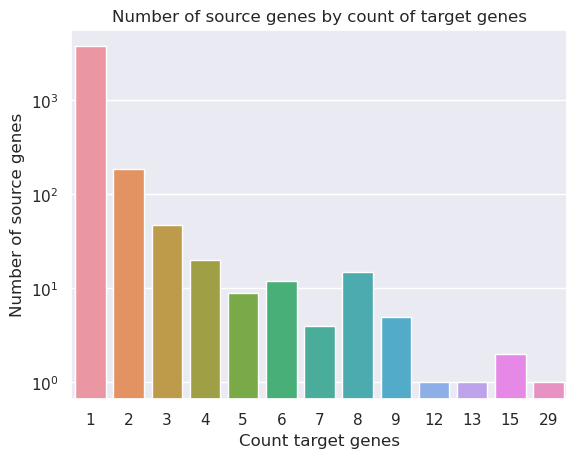

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,COLEC12 ENSDARG00000061140,Microglia
1,FOSAB ENSDARG00000031683,Microglia
2,CABZ01114581.1 ENSDARG00000112526,Microglia
3,MYO1F ENSDARG00000078734,Microglia
4,CD180 ENSDARG00000093750,Microglia
...,...,...
7288,LRRIQ1 ENSDARG00000093781,Olfactory epithelial cells
7289,NHLH2 ENSDARG00000025495,Retinal ganglion cells
7290,NHLH2 ENSDARG00000025495,Cajal-Retzius cells
7291,TUBA2 ENSDARG00000045014,Gamma delta T cells


In [24]:
filtered_source_df = calc.transfer_markers_biomart(biomart_db, source_df, target_genes, source_whitelist=source_genes,
                                                 calc_proportions=True, plots=True, target_counts=1)

2. Create DataFrame containing the transferred genes based on the filter criteria.

In [16]:
transferred_list = calc.transfer_markers_biomart(biomart_db, filtered_source_df, target_genes, source_whitelist=source_genes,
                                                 calc_proportions=True, plots=True, target_counts=None)
print("Transferred markers:")
display(transferred_list)

Marker transfer rate: 100.00%
Marker transfer rate after filtering: 0.00%
Possible transfer rate of all genes: 49.35%
Proportion of transferred genes in all genes of target organism: 66.16%
Transferred markers:


,Marker,Info
0,ENSGALG00010022028,Hematopoietic stem cells
1,ENSGALG00010022028,Endothelial cells (aorta)
2,ENSGALG00010012873,Microglia
3,ENSGALG00010002632,Macrophages
4,ENSGALG00010019283,Basophils
...,...,...
7272,ENSGALG00010016940,Astrocytes
7273,ENSGALG00010005249,Smooth muscle cells
7274,ENSGALG00010005249,Radial glia cells
7291,ENSGALG00010018026,Ciliated cells


3. Export transferred marker list

In [17]:
mr.export_marker_list(transferred_list, marker_id="symbol")

Enter file name or path: hallo
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/hallo


'/mnt/workspace/mkessle/projects/annotate_by_marker_and_features/hallo'

## Transfer markers from one organism to another using HomoloGene db

In [18]:
print(f"Source organism: {source_organism}\nTarget organism: {target_organism}")

Source organism: zebrafish
Target organism: chicken


### Preparations for gene transfer

Get HomoloGene db.

In [19]:
hg_db = calc.download_homologene_data()

'homologene.data' already exists. Do you want to overwrite it? (yes/no): no


Select all lists of source organism for cell type annotation.

In [ ]:
keywords = [source_organism, "Cell type annotation"]
source_df = mr.search_df(mr.get_db(), keywords, case_sensitive=True, exact=True, out="marker_list")

...<b>Or</b> select lists using guided search.

In [ ]:
source_df = mr.guided_search(out="marker_list")

In [20]:
display(source_df)

,Marker,Info
0,COLEC12 ENSDARG00000061140,Microglia
1,FOSAB ENSDARG00000031683,Microglia
2,CABZ01114581.1 ENSDARG00000112526,Microglia
3,MYO1F ENSDARG00000078734,Microglia
4,CD180 ENSDARG00000093750,Microglia
...,...,...
26187,KRT15 ENSDARG00000036840,Salivary mucous cells
26188,CYT1 ENSDARG00000092947,Salivary mucous cells
26189,KRT1-19D ENSDARG00000023082,Salivary mucous cells
26190,KRT17 ENSDARG00000094041,Salivary mucous cells


### Transfer source markers to target markers using HomoloGene db and extend transferred markers.

1. Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than <b>target_counts</b> target genes.

Marker transfer rate: 42.41%
Marker transfer rate after filtering: 35.01%
Possible transfer rate of all genes: 46.10%
Proportion of transferred genes in all genes of target organism: 108.63%

Count of target genes per source gene:


,Source Gene,Count target genes
6715,MHC1ZBA ENSDARG00000036588,24
6716,MHC1ZJA ENSDARG00000074765,24
5624,LOC556263,24
6124,LOC571502,24
9595,SI:CH211-287J19.6,24
...,...,...
4208,KLF4A,1
4209,KLF4B,1
4210,KLF6A ENSDARG00000029072,1
4211,KLF7A ENSDARG00000073857,1


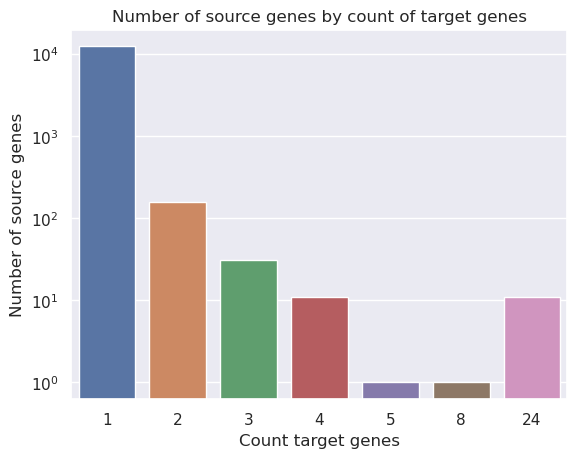

Filtered source DataFrame with target_counts <= 10:


,Marker,Info
0,COLEC12 ENSDARG00000061140,Microglia
1,MYO1F ENSDARG00000078734,Microglia
2,APBB1IP ENSDARG00000016505,Microglia
3,APBB1IP ENSDARG00000016505,T memory cells
4,CMTM6 ENSDARG00000099631,Microglia
...,...,...
4803,FOXE1 ENSDARG00000079266,Follicular cells
4804,ZGC:173729 ENSDARG00000057263,Microfold cells
4805,SERPINB1L1 ENSDARG00000095830,Microfold cells
4806,SERPINB1L3 ENSDARG00000014556,Microfold cells


In [21]:
filtered_source_df = calc.transfer_markers(source_df, source_tax, target_tax, hg_db, target_genes,
                                           source_whitelist=source_genes, calc_proportions=True, plots=True, 
                                           target_counts=10)

2. Create DataFrame containing the transferred genes based on the filter criteria.

In [22]:
transferred_list = calc.transfer_markers(filtered_source_df, source_tax, target_tax, hg_db, target_genes,
                                         source_whitelist=source_genes, calc_proportions=True, plots=True)
print("Transferred markers:")
display(transferred_list)

Marker transfer rate: 89.04%
Marker transfer rate after filtering: 77.04%
Possible transfer rate of all genes: 46.10%
Proportion of transferred genes in all genes of target organism: 108.63%
Transferred markers:


,Marker,Info
0,COLEC12 ENSGALG00000014910,Microglia
1,MYO1F ENSGALG00000001571,Microglia
2,APBB1IP ENSGALG00000007579,Microglia
3,APBB1IP ENSGALG00000007579,T memory cells
4,CMTM6 ENSGALG00000011490,Microglia
...,...,...
4918,VAMP1 ENSGALG00000049853,Trigeminal neurons
4920,GTSF1,Germ cells
4921,ACYP1 ENSGALG00000010307,Germ cells
4922,FOXE1,Follicular cells


3. Export transferred marker list

In [23]:
mr.export_marker_list(transferred_list, marker_id="symbol")

Enter file name or path: tach
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/tach


'/mnt/workspace/mkessle/projects/annotate_by_marker_and_features/tach'